# Telecom Customer Churn: Factor Identification and Prediction Using Machine Learning

**Project Title:** ტელეკომუნიკაციის მომხმარებელთა გადინების განმაპირობებელი ფაქტორების იდენტიფიცირება და პროგნოზირება მანქანური სწავლების მეთოდებით

**Author:** Mariam Tsintsadze  
**Supervisor:** Prof. Maxim Iavich  
**University:** Caucasus University, School of Technology  

---

## Table of Contents
1. [Import Libraries & Load Data](#1)
2. [Data Cleaning](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Statistical Testing](#4)
5. [Feature Engineering & Preprocessing](#5)
6. [Customer Segmentation](#6)
7. [Model Building (Without SMOTE - Baseline)](#7)
8. [Model Building (With SMOTE)](#8)
9. [Hyperparameter Tuning](#9)
10. [Model Evaluation & Comparison](#10)
11. [Precision-Recall Tradeoff & Threshold Optimization](#11)
12. [SHAP Analysis - Factor Identification](#12)
13. [LIME Validation](#13)
14. [Churn Risk Scoring System](#14)
15. [Business Recommendations](#15)
16. [Pipeline Summary](#16)
17. [Conclusion](#17)

---
<a id="1"></a>
## 1. Import Libraries & Load Data

In [22]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve
)

from sklearn.preprocessing import StandardScaler as SC
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    silhouette_score
)

from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("All libraries imported successfully.")

All libraries imported successfully.


In [23]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
print("Dataset Info:")
print("=" * 50)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [25]:
print("\nStatistical Summary (Numerical):")
df.describe()


Statistical Summary (Numerical):


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [26]:
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0


---
<a id="2"></a>
## 2. Data Cleaning

### 2.1 Data Type Verification

In [27]:
print("DATA TYPE VERIFICATION")
print("=" * 60)
print(f"{'Column':<20}{'Current Type':<15}{'Expected Type':<15}{'Status'}")
print("-" * 60)

expected_types = {
    'customerID': 'object', 'gender': 'object', 'SeniorCitizen': 'int64',
    'Partner': 'object', 'Dependents': 'object', 'tenure': 'int64',
    'PhoneService': 'object', 'MultipleLines': 'object', 'InternetService': 'object',
    'OnlineSecurity': 'object', 'OnlineBackup': 'object', 'DeviceProtection': 'object',
    'TechSupport': 'object', 'StreamingTV': 'object', 'StreamingMovies': 'object',
    'Contract': 'object', 'PaperlessBilling': 'object', 'PaymentMethod': 'object',
    'MonthlyCharges': 'float64', 'TotalCharges': 'float64', 'Churn': 'object'
}

issues_found = []
for col in df.columns:
    actual = str(df[col].dtype)
    expected = expected_types.get(col, 'unknown')
    if actual != expected:
        status = "Needs conversion"
        issues_found.append(col)
    else:
        status = "OK"
    print(f"{col:<20}{actual:<15}{expected:<15}{status}")

print("=" * 60)
print(f"\nIssues found: {len(issues_found)}")
if issues_found:
    print(f"  → {issues_found} — needs conversion")

DATA TYPE VERIFICATION
Column              Current Type   Expected Type  Status
------------------------------------------------------------
customerID          object         object         OK
gender              object         object         OK
SeniorCitizen       int64          int64          OK
Partner             object         object         OK
Dependents          object         object         OK
tenure              int64          int64          OK
PhoneService        object         object         OK
MultipleLines       object         object         OK
InternetService     object         object         OK
OnlineSecurity      object         object         OK
OnlineBackup        object         object         OK
DeviceProtection    object         object         OK
TechSupport         object         object         OK
StreamingTV         object         object         OK
StreamingMovies     object         object         OK
Contract            object         object         OK
PaperlessBi

### 2.2 Whitespace & Inconsistency Check in Categorical Columns

In [28]:
print("CATEGORICAL VALUE CONSISTENCY CHECK")
print("=" * 60)

cat_cols_check = df.select_dtypes(include='object').columns.tolist()
inconsistencies = 0

for col in cat_cols_check:
    unique_vals = df[col].unique()
    # Check for leading/trailing whitespace
    whitespace_issues = [v for v in unique_vals if isinstance(v, str) and (v != v.strip())]
    # Check for empty strings
    empty_issues = [v for v in unique_vals if isinstance(v, str) and v.strip() == '']
    
    if whitespace_issues or empty_issues:
        print(f"  ⚠ {col}: Found {len(whitespace_issues)} whitespace issues, {len(empty_issues)} empty values")
        inconsistencies += 1
    else:
        n_unique = len(unique_vals)
        print(f"  ✓ {col}: {n_unique} unique values — clean")

print("=" * 60)
if inconsistencies == 0:
    print("\n All categorical columns are clean — no whitespace or inconsistency issues.")
else:
    print(f"\n {inconsistencies} columns need cleaning.")

CATEGORICAL VALUE CONSISTENCY CHECK
  ✓ customerID: 7043 unique values — clean
  ✓ gender: 2 unique values — clean
  ✓ Partner: 2 unique values — clean
  ✓ Dependents: 2 unique values — clean
  ✓ PhoneService: 2 unique values — clean
  ✓ MultipleLines: 3 unique values — clean
  ✓ InternetService: 3 unique values — clean
  ✓ OnlineSecurity: 3 unique values — clean
  ✓ OnlineBackup: 3 unique values — clean
  ✓ DeviceProtection: 3 unique values — clean
  ✓ TechSupport: 3 unique values — clean
  ✓ StreamingTV: 3 unique values — clean
  ✓ StreamingMovies: 3 unique values — clean
  ✓ Contract: 3 unique values — clean
  ✓ PaperlessBilling: 2 unique values — clean
  ✓ PaymentMethod: 4 unique values — clean
  ⚠ TotalCharges: Found 1 whitespace issues, 1 empty values
  ✓ Churn: 2 unique values — clean

 1 columns need cleaning.


### 2.3 Missing Values Analysis

In [29]:
# Convert TotalCharges to numeric to reveal hidden missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("MISSING VALUES ANALYSIS")
print("=" * 60)
print(f"{'Column':<20}{'Missing':<10}{'% Missing':<12}{'Action'}")
print("-" * 60)

for col in df.columns:
    missing = df[col].isnull().sum()
    pct = missing / len(df) * 100
    if missing > 0:
        action = "Fill with 0 (new customers)"
        print(f"{col:<20}{missing:<10}{pct:<12.2f}{action}")
    
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("  No missing values found in any column.")
else:
    print(f"\nTotal missing values: {total_missing}")
    print(f"Affected rows: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).sum()/len(df)*100:.2f}%)")

print("=" * 60)

# Fix: Fill TotalCharges NaN with 0
print(f"\nCustomers with missing TotalCharges (tenure = 0, new customers):")
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges']].head(11))
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"\nMissing TotalCharges filled with 0. Remaining missing: {df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS
Column              Missing   % Missing   Action
------------------------------------------------------------
TotalCharges        11        0.16        Fill with 0 (new customers)

Total missing values: 11
Affected rows: 11 (0.16%)

Customers with missing TotalCharges (tenure = 0, new customers):
      customerID  tenure  MonthlyCharges
488   4472-LVYGI       0           52.55
753   3115-CZMZD       0           20.25
936   5709-LVOEQ       0           80.85
1082  4367-NUYAO       0           25.75
1340  1371-DWPAZ       0           56.05
3331  7644-OMVMY       0           19.85
3826  3213-VVOLG       0           25.35
4380  2520-SGTTA       0           20.00
5218  2923-ARZLG       0           19.70
6670  4075-WKNIU       0           73.35
6754  2775-SEFEE       0           61.90

Missing TotalCharges filled with 0. Remaining missing: 0


### 2.4 Duplicate Records Check

In [30]:
duplicates = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print("DUPLICATE RECORDS CHECK")
print("=" * 40)
print(f"  Exact duplicate rows: {duplicates}")
print(f"  Duplicate customerIDs: {duplicate_ids}")

if duplicates == 0 and duplicate_ids == 0:
    print("\n No duplicates found — each row represents a unique customer.")
else:
    print(f"\n Found duplicates — removing...")
    df = df.drop_duplicates()

DUPLICATE RECORDS CHECK
  Exact duplicate rows: 0
  Duplicate customerIDs: 0

 No duplicates found — each row represents a unique customer.


### 2.5 Outlier Detection (IQR Method)

In [31]:
numerical_cols_outlier = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("OUTLIER ANALYSIS (IQR Method)")
print("=" * 70)
print(f"{'Feature':<18}{'Q1':<10}{'Q3':<10}{'IQR':<10}{'Lower':<10}{'Upper':<10}{'Outliers':<10}")
print("-" * 70)

for col in numerical_cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:<18}{Q1:<10.1f}{Q3:<10.1f}{IQR:<10.1f}{lower:<10.1f}{upper:<10.1f}{outliers:<10}")

print("=" * 70)
if outliers == 0:
    print("\n No outliers detected in numerical features.")
else:
    print(f"\nTotal outliers detected across all numerical features: {outliers}")

OUTLIER ANALYSIS (IQR Method)
Feature           Q1        Q3        IQR       Lower     Upper     Outliers  
----------------------------------------------------------------------
tenure            9.0       55.0      46.0      -60.0     124.0     0         
MonthlyCharges    35.5      89.8      54.3      -46.0     171.4     0         
TotalCharges      398.6     3786.6    3388.0    -4683.5   8868.7    0         

 No outliers detected in numerical features.


### 2.6 Data Cleaning Summary

DATA CLEANING SUMMARY

  1. Dataset shape: (7043, 21)
  2. Total missing values: 0 (fixed)
  3. Duplicates removed: 0
  4. Outliers: None found
  5. Type corrections: TotalCharges (object → float64)
  6. Whitespace issues: None found

✓ Dataset is clean and ready for feature engineering.

---
<a id="3"></a>
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

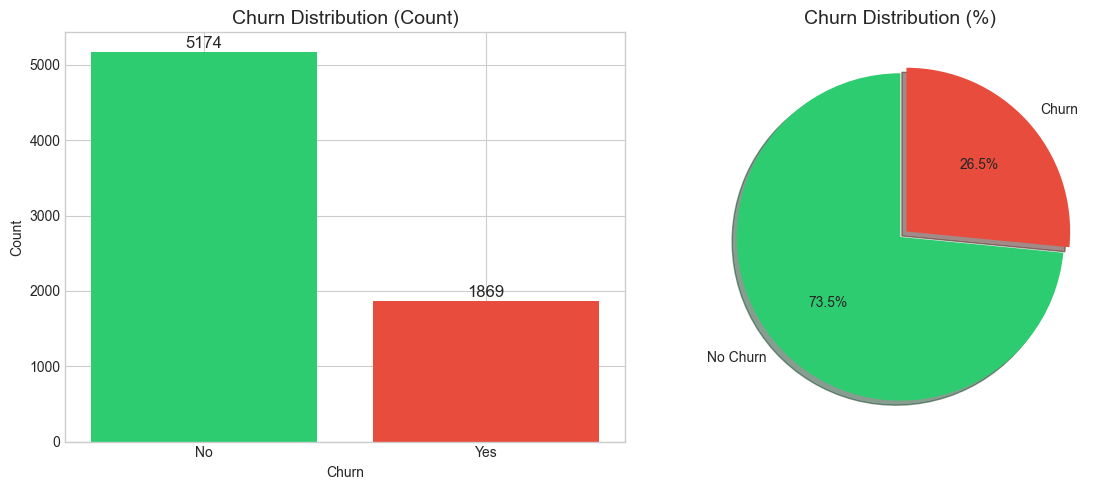

No Churn: 5174 (73.5%)
Churn: 1869 (26.5%)


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.05), shadow=True, startangle=90)
axes[1].set_title('Churn Distribution (%)', fontsize=14)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"No Churn: {churn_counts['No']} ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"Churn: {churn_counts['Yes']} ({churn_counts['Yes']/len(df)*100:.1f}%)")

### 3.2 Demographic Analysis

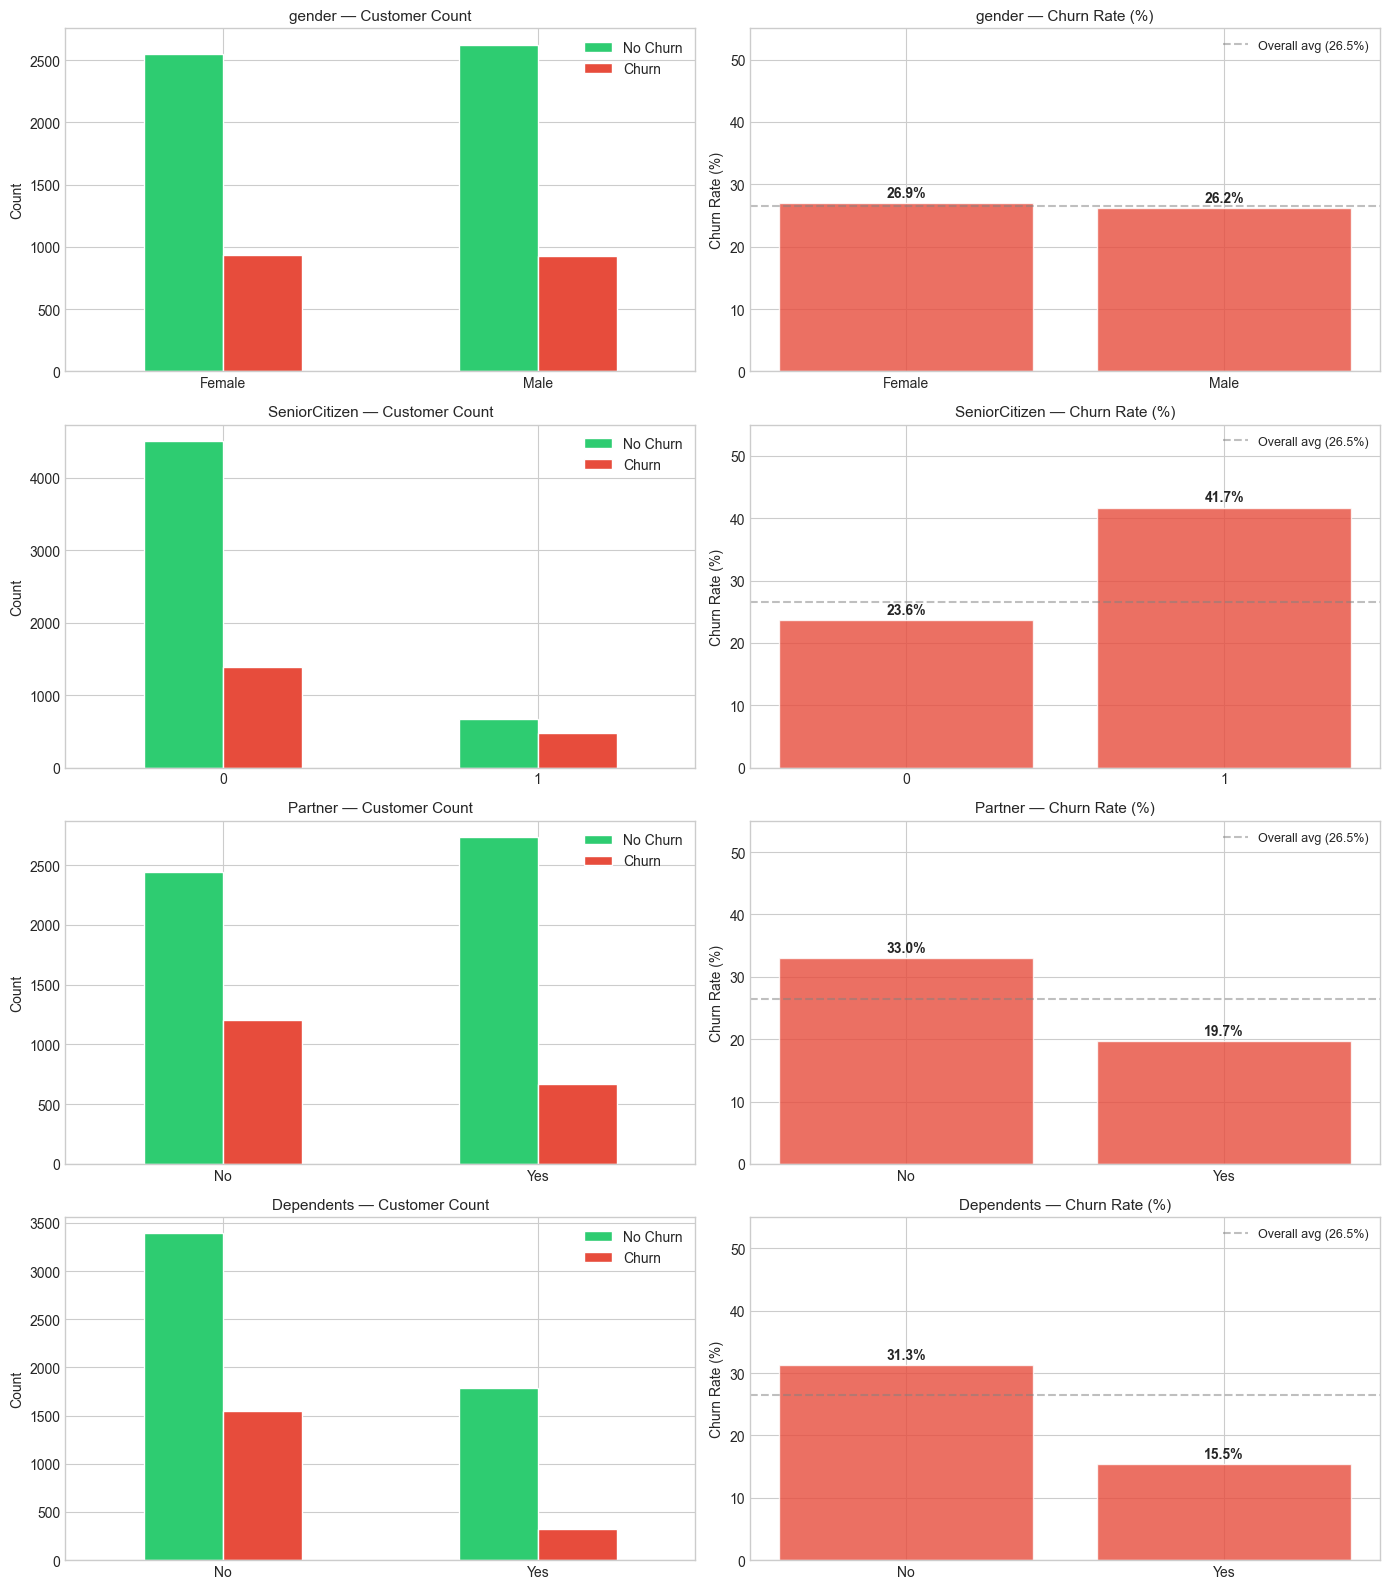

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for idx, col in enumerate(demo_cols):
    # Left: Count distribution
    ax_count = axes[idx, 0]
    counts = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    counts.plot(kind='bar', ax=ax_count, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax_count.set_title(f'{col} — Customer Count', fontsize=11)
    ax_count.set_ylabel('Count')
    ax_count.set_xlabel('')
    ax_count.legend(['No Churn', 'Churn'], loc='upper right')
    ax_count.tick_params(axis='x', rotation=0)
    
    # Right: Churn rate
    ax_rate = axes[idx, 1]
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    bars = ax_rate.bar(range(len(churn_rate)), churn_rate.values, 
                       color='#e74c3c', edgecolor='white', alpha=0.8)
    ax_rate.set_xticks(range(len(churn_rate)))
    ax_rate.set_xticklabels(churn_rate.index)
    ax_rate.set_title(f'{col} — Churn Rate (%)', fontsize=11)
    ax_rate.set_ylabel('Churn Rate (%)')
    ax_rate.set_ylim(0, 55)
    ax_rate.axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Overall avg (26.5%)')
    ax_rate.legend(fontsize=9)
    for j, v in enumerate(churn_rate.values):
        ax_rate.text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Service-Related Analysis

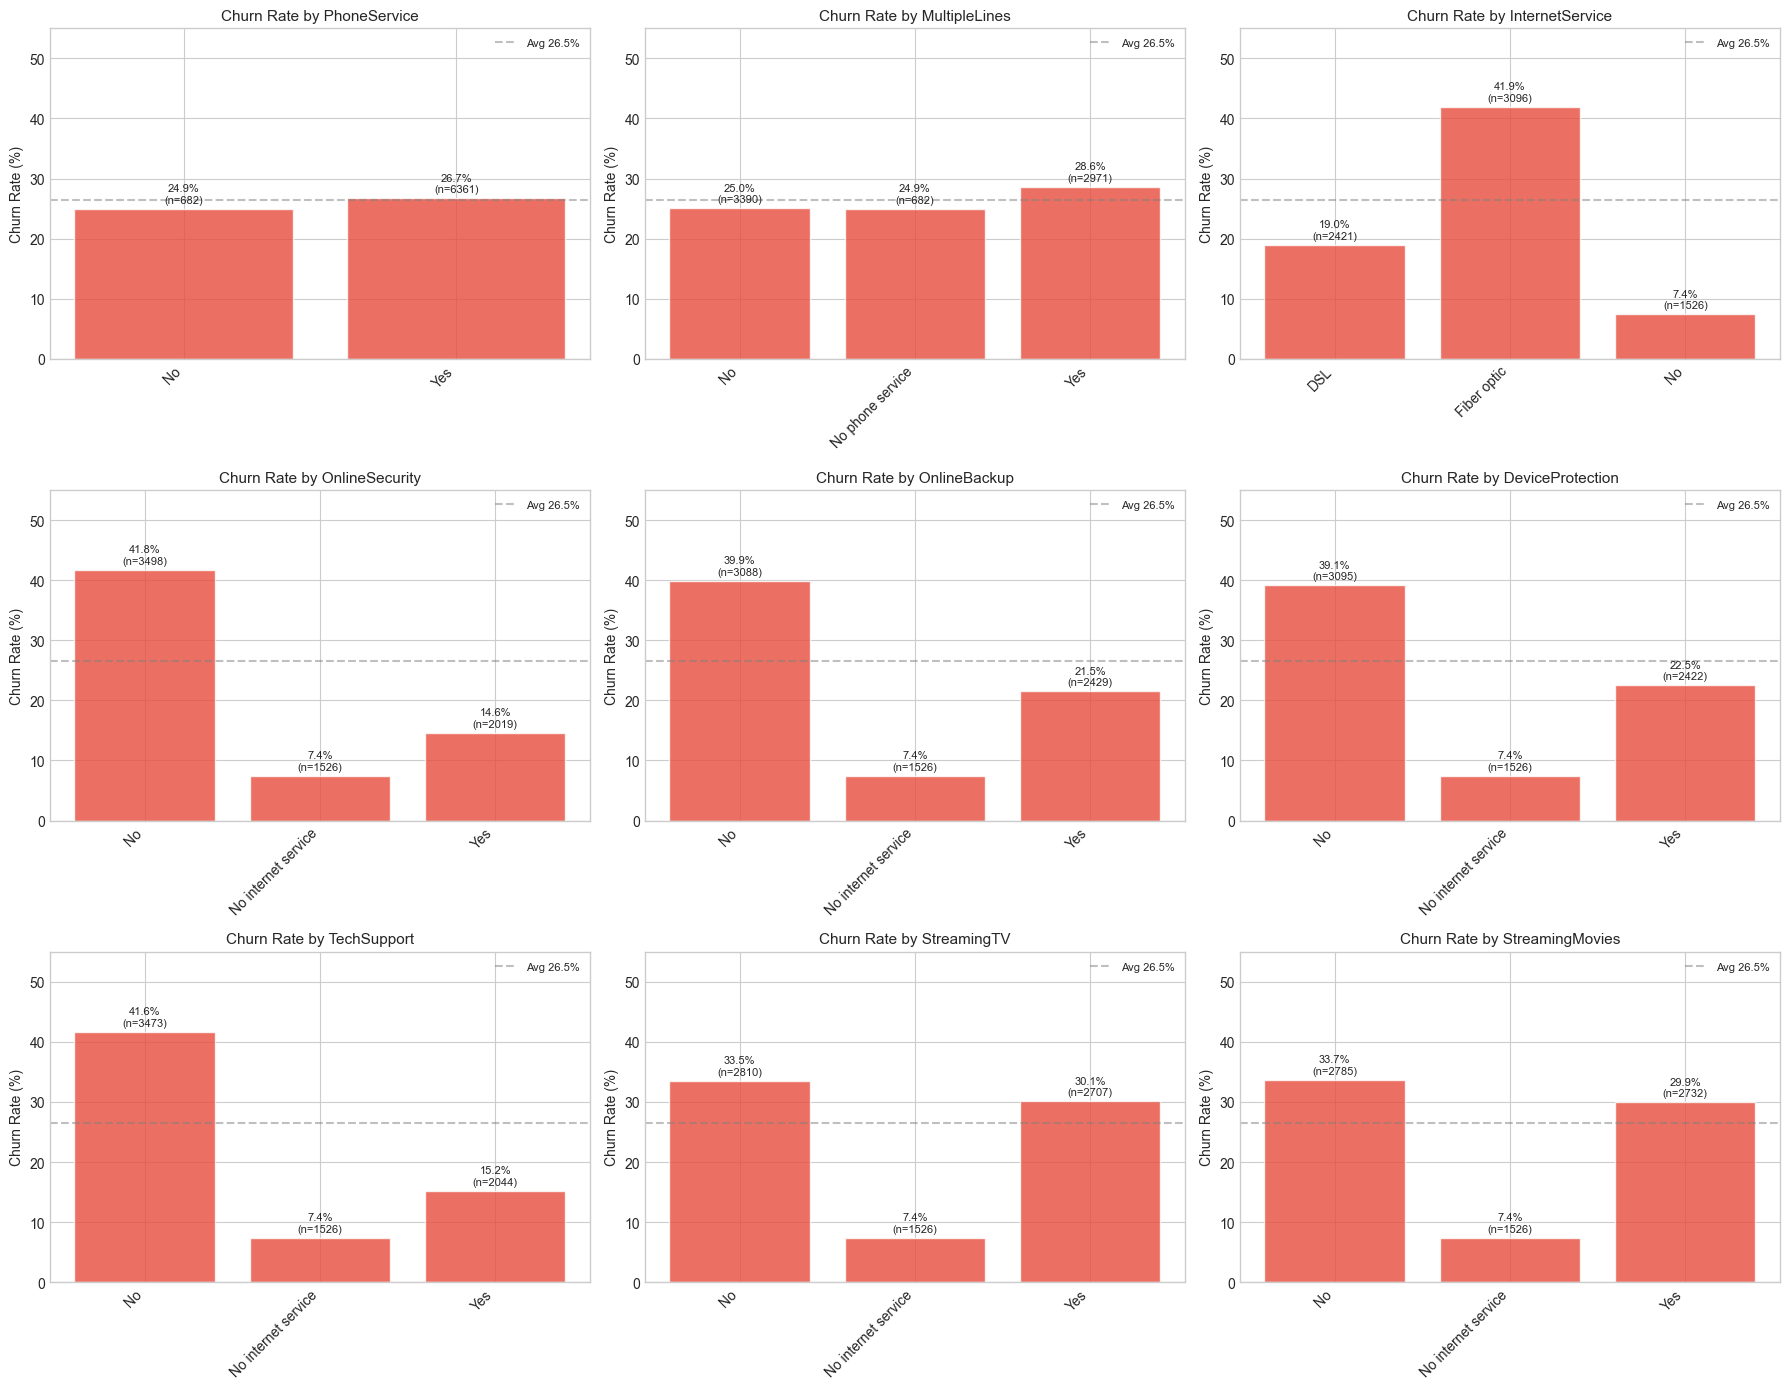

In [34]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    group_size = df.groupby(col).size()
    
    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values, 
                       color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=45, ha='right')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_ylim(0, 55)
    axes[i].axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Avg 26.5%')
    axes[i].legend(fontsize=8)
    # Show rate AND count (n=) on each bar
    for j, (rate, n) in enumerate(zip(churn_rate.values, group_size.values)):
        axes[i].text(j, rate + 1, f'{rate:.1f}%\n(n={n})', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('service_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Contract and Billing Analysis

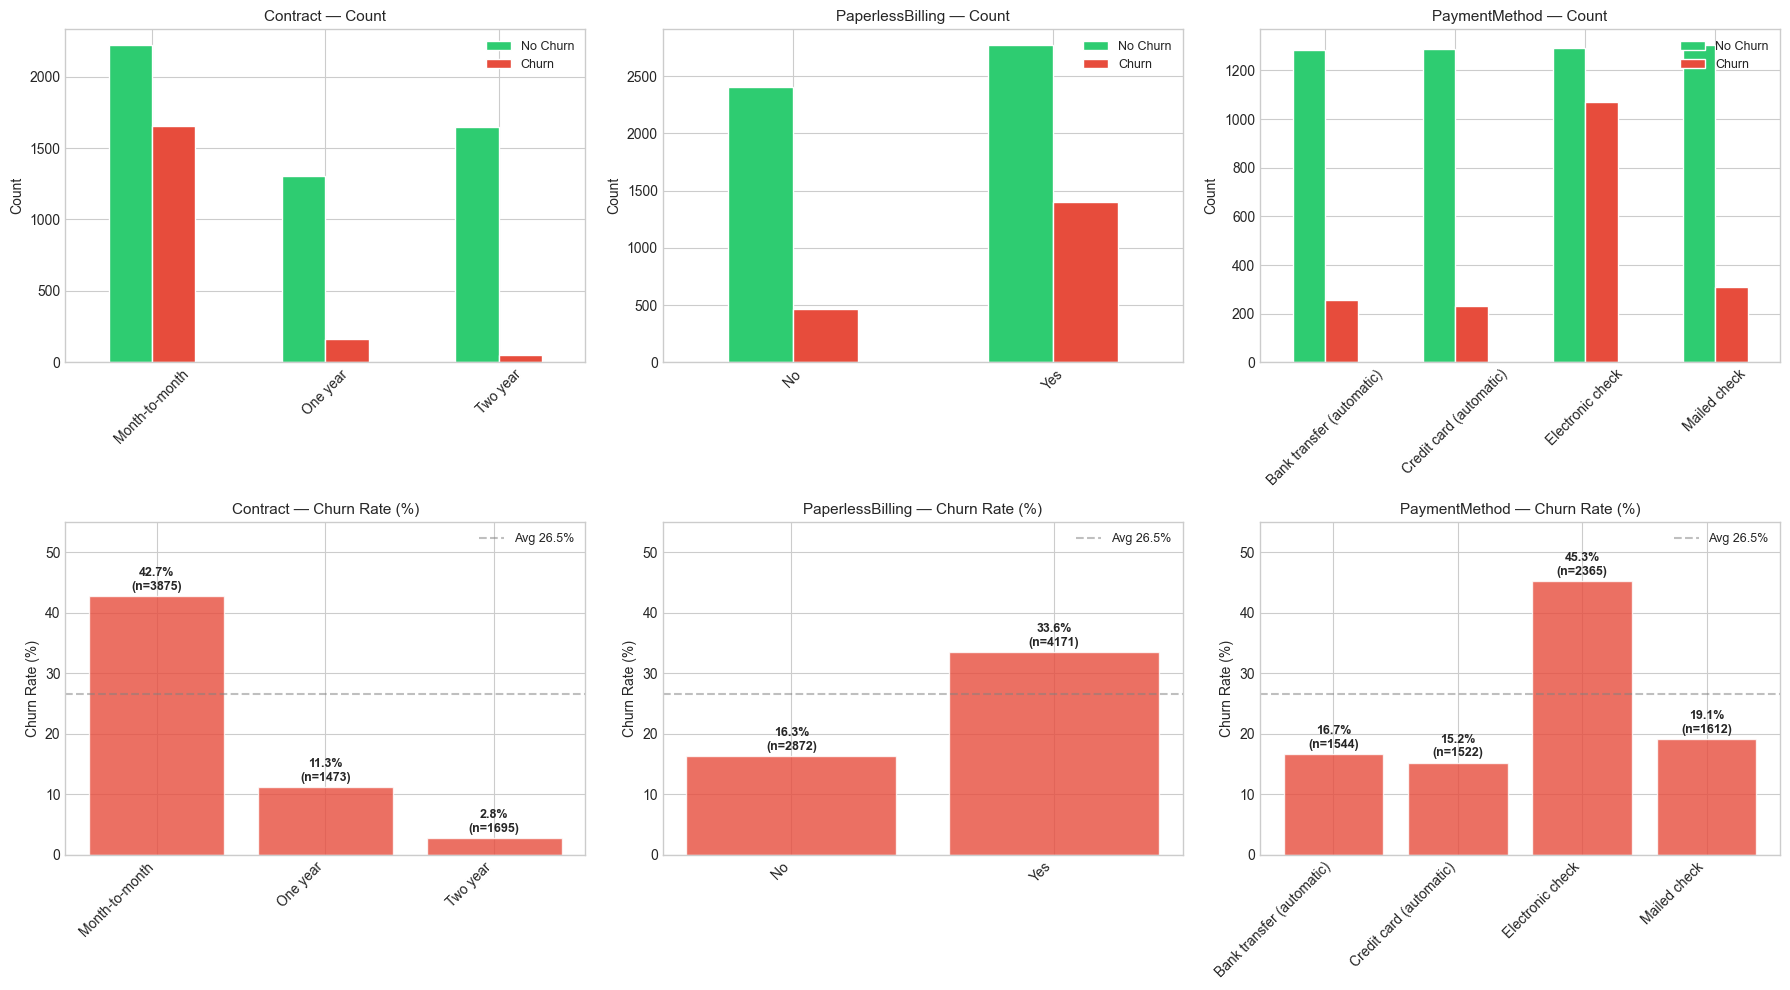

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

billing_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

for idx, col in enumerate(billing_cols):
    # Top row: Counts
    ax_count = axes[0, idx]
    counts = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    counts.plot(kind='bar', ax=ax_count, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax_count.set_title(f'{col} — Count', fontsize=11)
    ax_count.set_ylabel('Count')
    ax_count.set_xlabel('')
    ax_count.legend(['No Churn', 'Churn'], fontsize=9)
    ax_count.tick_params(axis='x', rotation=45)
    
    # Bottom row: Churn rate
    ax_rate = axes[1, idx]
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
    group_size = df.groupby(col).size()
    bars = ax_rate.bar(range(len(churn_rate)), churn_rate.values, 
                       color='#e74c3c', edgecolor='white', alpha=0.8)
    ax_rate.set_xticks(range(len(churn_rate)))
    ax_rate.set_xticklabels(churn_rate.index, rotation=45, ha='right')
    ax_rate.set_ylabel('Churn Rate (%)')
    ax_rate.set_title(f'{col} — Churn Rate (%)', fontsize=11)
    ax_rate.set_ylim(0, 55)
    ax_rate.axhline(y=26.5, color='gray', linestyle='--', alpha=0.5, label='Avg 26.5%')
    ax_rate.legend(fontsize=9)
    for j, (rate, n) in enumerate(zip(churn_rate.values, group_size.values)):
        ax_rate.text(j, rate + 1, f'{rate:.1f}%\n(n={n})', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('contract_billing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Numerical Features Analysis

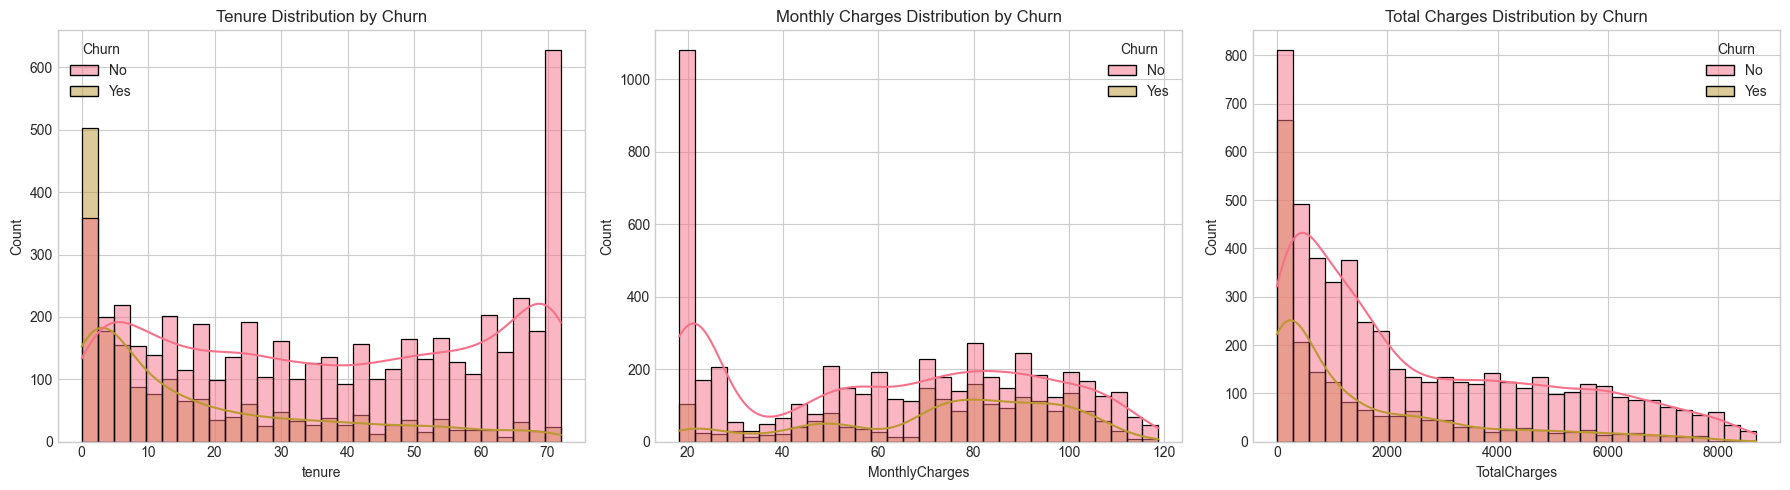

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], bins=30)
axes[0].set_title('Tenure Distribution by Churn')

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1], bins=30)
axes[1].set_title('Monthly Charges Distribution by Churn')

sns.histplot(data=df.dropna(subset=['TotalCharges']), x='TotalCharges', hue='Churn', kde=True, ax=axes[2], bins=30)
axes[2].set_title('Total Charges Distribution by Churn')

plt.tight_layout()
plt.savefig('numerical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# bins start at -1 (not 0) to make the first interval (-1, 12],
# which correctly includes tenure=0 customers (new customers with no billing yet).
# Starting at 0 would create (0, 12] which silently drops tenure=0 as NaN.
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72],
                            labels=['0-12', '13-24', '25-48', '49-72'])

# Verify no NaN tenure groups (would indicate customers were dropped)
nan_groups = df['tenure_group'].isnull().sum()
if nan_groups == 0:
    print("\n Tenure groups assigned successfully to all customers.")
else:
    print(f"\n Warning: {nan_groups} customers have no tenure group assigned.")
    print("Check tenure values outside the defined bins.")

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
print("\nChurn Rate by Tenure Group:")
print(churn_by_tenure.to_string())
print("\nGroup '0-12' represents the highest-risk period for customer churn.")


 Tenure groups assigned successfully to all customers.

Churn Rate by Tenure Group:
tenure_group
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-72     9.513176

Group '0-12' represents the highest-risk period for customer churn.


### 3.6 Correlation Analysis

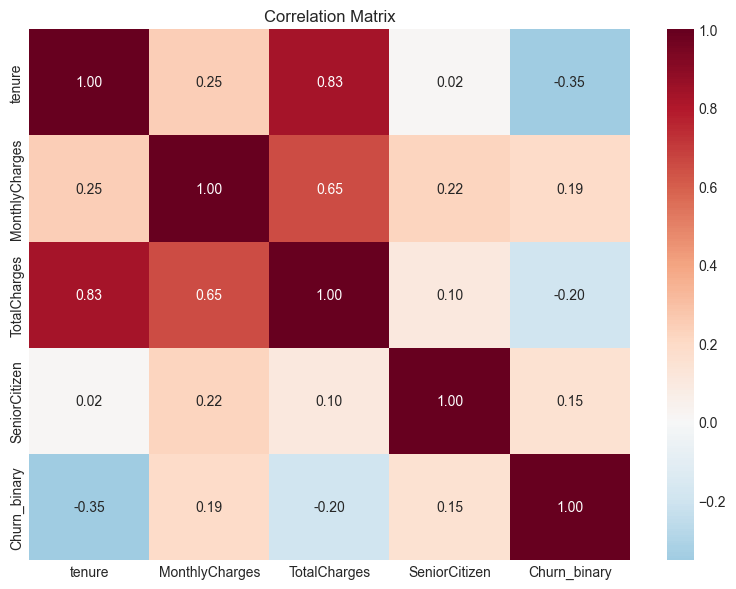

In [38]:
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 EDA Key Insights Summary

Based on the exploratory analysis above, the following key observations emerge:

1. **Class Imbalance**: The dataset is imbalanced — only ~26.5% of customers churned. This needs to be addressed during modeling to avoid bias toward the majority class.

2. **Contract Type is Critical**: Month-to-month customers churn at dramatically higher rates than those on 1-year or 2-year contracts. Long-term contracts act as a strong retention mechanism.

3. **Tenure Matters**: New customers (0-12 months) have the highest churn rate. Churn decreases significantly as tenure increases, suggesting the first year is the most vulnerable period.

4. **Security/Support Services Reduce Churn**: Customers without Online Security or Tech Support show noticeably higher churn rates. These services appear to increase customer "stickiness."

5. **Payment Method Signal**: Electronic check users churn more than those using automatic payment methods (credit card, bank transfer). This may indicate less commitment or engagement.

6. **Higher Monthly Charges = Higher Churn**: Customers paying more per month are more likely to leave, especially when they don't perceive value from additional services.

---
<a id="4"></a>
## 4. Statistical Testing

To validate our EDA observations statistically, we perform:
- **Chi-Square Test** for categorical features (is the association with churn statistically significant?)
- **Independent Samples T-Test** for numerical features (is the mean difference significant?)

### 4.1 Chi-Square Test for Categorical Features

In [39]:
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                        'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaperlessBilling', 'PaymentMethod']

chi2_results = []
for col in categorical_features:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        'Feature': col,
        'Chi-Square': round(chi2, 2),
        'P-Value': p_value,
        'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi-Square', ascending=False)
print("CHI-SQUARE TEST RESULTS")
print("=" * 70)
print(f"{'Feature':<20}{'Chi-Square':<15}{'P-Value':<15}{'Significant?'}")
print("-" * 70)
for _, row in chi2_df.iterrows():
    sig = "Yes" if row['Significant (p<0.05)'] == 'Yes' else "No"
    print(f"{row['Feature']:<20}{row['Chi-Square']:<15.2f}{row['P-Value']:<15.6f}{sig}")
print("=" * 70)
print(f"\nSignificant features: {chi2_df[chi2_df['Significant (p<0.05)']=='Yes'].shape[0]}/{len(chi2_df)}")

CHI-SQUARE TEST RESULTS
Feature             Chi-Square     P-Value        Significant?
----------------------------------------------------------------------
Contract            1184.60        0.000000       Yes
OnlineSecurity      850.00         0.000000       Yes
TechSupport         828.20         0.000000       Yes
InternetService     732.31         0.000000       Yes
PaymentMethod       648.14         0.000000       Yes
OnlineBackup        601.81         0.000000       Yes
DeviceProtection    558.42         0.000000       Yes
StreamingMovies     375.66         0.000000       Yes
StreamingTV         374.20         0.000000       Yes
PaperlessBilling    258.28         0.000000       Yes
Dependents          189.13         0.000000       Yes
SeniorCitizen       159.43         0.000000       Yes
Partner             158.73         0.000000       Yes
MultipleLines       11.33          0.003464       Yes
PhoneService        0.92           0.338783       No
gender              0.48         

### 4.2 T-Test for Numerical Features

In [40]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

churners = df[df['Churn'] == 'Yes']
non_churners = df[df['Churn'] == 'No']

print("INDEPENDENT SAMPLES T-TEST RESULTS")
print("=" * 80)
print(f"{'Feature':<18}{'Mean (Churn)':<15}{'Mean (No Churn)':<17}{'T-Stat':<12}{'P-Value':<12}{'Sig?'}")
print("-" * 80)

for col in numerical_features:
    churn_vals = churners[col].dropna()
    no_churn_vals = non_churners[col].dropna()
    t_stat, p_value = ttest_ind(churn_vals, no_churn_vals)
    sig = "Yes" if p_value < 0.05 else "No"
    print(f"{col:<18}{churn_vals.mean():<15.2f}{no_churn_vals.mean():<17.2f}{t_stat:<12.2f}{p_value:<12.6f}{sig}")

print("=" * 80)
print("\n→ All numerical features show statistically significant differences between churners and non-churners (p < 0.05).")

INDEPENDENT SAMPLES T-TEST RESULTS
Feature           Mean (Churn)   Mean (No Churn)  T-Stat      P-Value     Sig?
--------------------------------------------------------------------------------
tenure            17.98          37.57            -31.58      0.000000    Yes
MonthlyCharges    74.44          61.27            16.54       0.000000    Yes
TotalCharges      1531.80        2549.91          -16.98      0.000000    Yes

→ All numerical features show statistically significant differences between churners and non-churners (p < 0.05).
